# CV analysis: pyrrole -25 C - 2026-05-22 16:06 (FORCE)

Pairs the scope **force**-sensor log with the potentiostat CV log from the same run.
**Two cycles**, +1 V -> -1 V -> +1 V at **3 mV/s** (~1334 s/cycle).

- Scope: `scope_log_20260522_160605_..._FORCE.csv` - force signal is on **CH2** (CH1 is 0).
- Potentiostat: `Potentiostat_measurements/05.22.26-neg25C_in_tissue_FORCE_3mVpersec.csv` (2 scans).

Scope and potentiostat were started simultaneously (offset = 0 s); the potentiostat header
timestamp is ignored. The per-sample interval `DT` is derived from the recorded voltage step
and the 3 mV/s scan rate (~0.331 s/sample) rather than hard-coded.

**Secondary y-axes (left panels):**
- Force = scope-V x **56.7 mN/V** (1x gain).
- Stress = Force / cross-sectional area, with **A = 3 mm x 1.467 mm = 4.401 mm^2**
  (1 mN/mm^2 = 1 kPa = 1e-3 MPa).


In [3]:
# Load both files, align (offset = 0), filter scope outliers, map to applied voltage + cycle index.

import io, csv
import numpy as np
import pandas as pd

SCOPE_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv'
POTEN_CSV = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv'
SCOPE_CHANNEL = 'ch2_MEAN_V'      # FORCE signal is on CH2 (CH1 is 0)

SCAN_RATE_V_PER_S = 0.0025          # 3 mV/s
WINDOW = 41                        # MAD outlier-filter rolling window (samples)
K = 5.0                            # outlier threshold (multiples of MAD)


# ---- 1. Potentiostat (UTF-16, 6-line header, N scans side by side) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('﻿', '')

lines = text.splitlines()
rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
rows = [r for r in rows if r and r[0]]
n_scans = len(rows[0]) // 2                       # 2 columns (V, microA) per scan
cols = []
for s in range(n_scans):
    cols += [f'v{s+1}', f'i{s+1}_uA']
poten = pd.DataFrame([[float(x) for x in r[:2*n_scans]] for r in rows], columns=cols)
n_per_scan = len(poten)
print(f'Potentiostat: {n_scans} scans (cycles), {n_per_scan} samples/scan')


# ---- 2. Derive sample interval from the recorded voltage step + scan rate ----
# Each scan ramps +1 V -> -1 V -> +1 V at a fixed 3 mV/s. The downward leg from
# sample 0 to the argmin spans a known voltage delta, so DT = |dV| / scan_rate.
# (More robust than hard-coding 0.2 s the way the 5 mV/s reference notebook did.)
v1 = poten['v1'].values
turn_idx = int(np.argmin(v1))
DT = abs(v1[0] - v1[turn_idx]) / turn_idx / SCAN_RATE_V_PER_S
per_scan_s = n_per_scan * DT
exp_total_s = n_scans * per_scan_s
print(f'Derived DT = {DT:.4f} s/sample  ->  {per_scan_s:.1f} s/cycle, {exp_total_s:.1f} s total')

t_scan = np.arange(n_per_scan) * DT
t_exp_full = np.concatenate([t_scan + s*per_scan_s for s in range(n_scans)])
v_applied_full = np.concatenate([poten[f'v{s+1}'].values for s in range(n_scans)])


# ---- 3. Scope log + alignment (offset = 0; scope and potentiostat started together) ----
# The potentiostat header's "Date and time measurement" does not reflect the true
# acquisition-start instant, so we ignore it and assume a simultaneous start.
scope = pd.read_csv(SCOPE_CSV)
scope['t_exp'] = scope['elapsed_s']
scope_in = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= exp_total_s)].copy()
print(f'Scope rows in experiment window: {len(scope_in)} / {len(scope)} '
      f'(max elapsed {scope["elapsed_s"].max():.1f} s)')


# ---- 4. Outlier filter (rolling-median + MAD) ----
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    abs_dev = (s - med).abs()
    mad = abs_dev.rolling(window, center=True, min_periods=1).median()
    mad_floor = max(np.nanstd(x) * 1e-3, 1e-9)
    mad = mad.clip(lower=mad_floor)
    return (abs_dev > k * mad).values

mask = mark_outliers(scope_in[SCOPE_CHANNEL].values, window=WINDOW, k=K)
print(f'Flagged {mask.sum()} of {len(scope_in)} in-window scope samples '
      f'({mask.sum()/max(len(scope_in),1)*100:.2f}%) as outliers.')
scope_clean = scope_in.loc[~mask].copy()


# ---- 5. Map scope samples to applied voltage + cycle index ----
scope_clean['v_applied'] = np.interp(scope_clean['t_exp'].values, t_exp_full, v_applied_full)
scope_clean['cycle'] = np.clip((scope_clean['t_exp'].values // per_scan_s).astype(int), 0, n_scans-1)
for c in range(n_scans):
    print(f'Cycle {c+1} scope rows:', (scope_clean['cycle'] == c).sum())
scope_clean.head()


Potentiostat: 3 scans (cycles), 4034 samples/scan
Derived DT = 0.3967 s/sample  ->  1600.4 s/cycle, 4801.3 s total
Scope rows in experiment window: 9675 / 9892 (max elapsed 4908.7 s)
Flagged 0 of 9675 in-window scope samples (0.00%) as outliers.
Cycle 1 scope rows: 3223
Cycle 2 scope rows: 3226
Cycle 3 scope rows: 3226


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp,v_applied,cycle
0,0.4565,2026-06-03T14:12:24.808779,0.0,3.647688,0.4565,0.998874,0
1,0.9524,2026-06-03T14:12:25.304712,0.0,3.646300,0.9524,0.997636,0
2,1.4403,2026-06-03T14:12:25.792623,0.0,3.644660,1.4403,0.996434,0
3,1.9077,2026-06-03T14:12:26.259975,0.0,3.642972,1.9077,0.995237,0
4,2.4093,2026-06-03T14:12:26.761576,0.0,3.641300,2.4093,0.994031,0


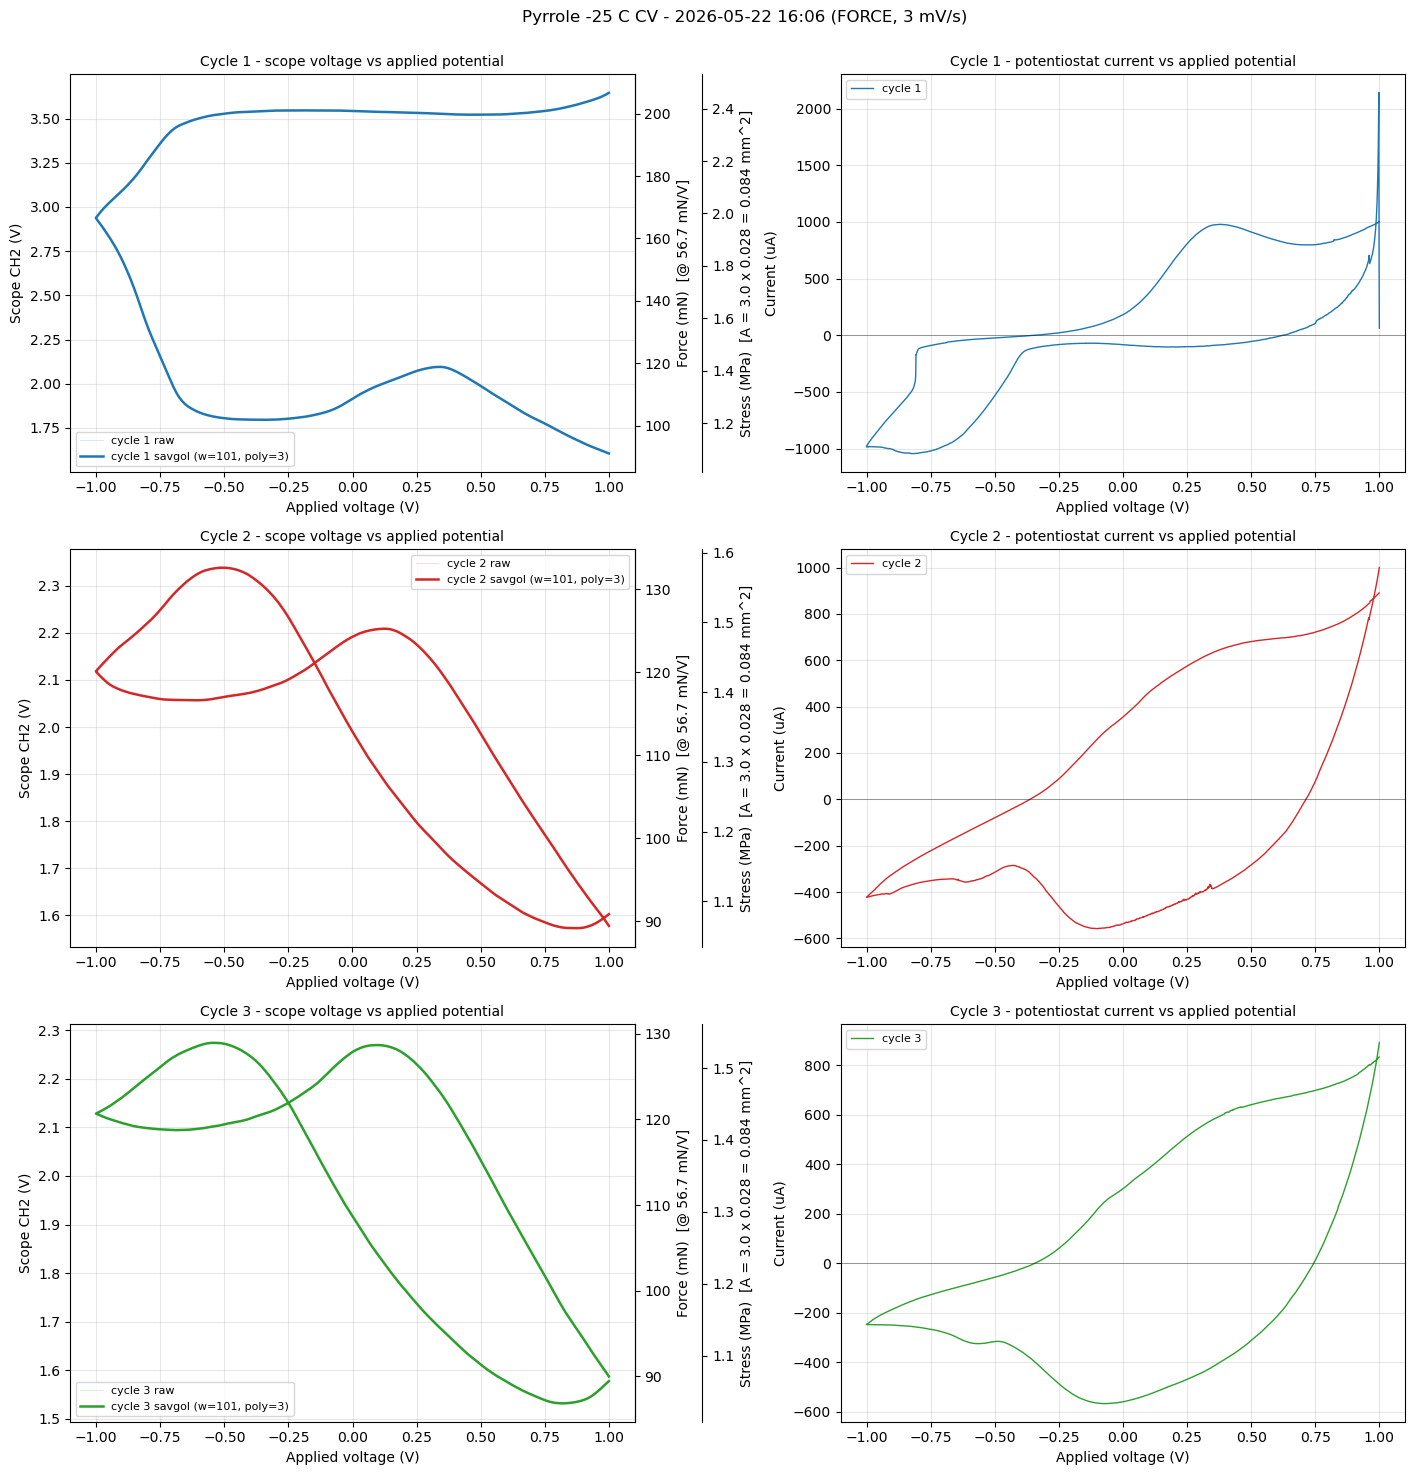

Stress conversion: 0.6750 MPa per scope-V


In [4]:
# Plot: rows = cycles, columns = (scope voltage with force/stress axes, potentiostat current).
# All x-axes are the applied voltage from the potentiostat.

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- Sample geometry / calibration (FORCE) ---
FORCE_GAIN_MN_PER_V = 56.7              # 1x gain
WIDTH_MM = 3.0
THICKNESS_MM = 0.028
AREA_MM2 = WIDTH_MM * THICKNESS_MM      # 4.401 mm^2 (cross-section perpendicular to force)
STRESS_PER_V_MPA = FORCE_GAIN_MN_PER_V / AREA_MM2 / 1000.0   # MPa per scope-V

PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
SMOOTH_WINDOW, SAVGOL_POLY, RAW_ALPHA = 101, 3, 0.20


def savgol_per_cycle(df, value_col, window=101, poly=3):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp')
        y = sub[value_col].values
        n = len(y)
        if n < 3:
            out.loc[sub.index] = y
            continue
        w = min(window, n)
        if w % 2 == 0:
            w -= 1
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out


scope_clean['smooth'] = savgol_per_cycle(scope_clean, SCOPE_CHANNEL, SMOOTH_WINDOW, SAVGOL_POLY)

fig, axes = plt.subplots(n_scans, 2, figsize=(15, 5*n_scans), squeeze=False)
for c in range(n_scans):
    color = PALETTE[c % len(PALETTE)]
    sub = scope_clean[scope_clean['cycle'] == c].sort_values('t_exp')

    # --- left: scope voltage with force + stress secondary axes ---
    ax = axes[c, 0]
    ax.plot(sub['v_applied'], sub[SCOPE_CHANNEL], color=color, lw=0.6, alpha=RAW_ALPHA,
            label=f'cycle {c+1} raw')
    ax.plot(sub['v_applied'], sub['smooth'], color=color, lw=1.8,
            label=f'cycle {c+1} savgol (w={SMOOTH_WINDOW}, poly={SAVGOL_POLY})')
    ax.set_xlabel('Applied voltage (V)')
    ax.set_ylabel('Scope CH2 (V)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    ax_f = ax.secondary_yaxis('right',
        functions=(lambda v: v*FORCE_GAIN_MN_PER_V, lambda mn: mn/FORCE_GAIN_MN_PER_V))
    ax_f.set_ylabel(f'Force (mN)  [@ {FORCE_GAIN_MN_PER_V} mN/V]')
    ax_s = ax.secondary_yaxis(1.12,
        functions=(lambda v: v*STRESS_PER_V_MPA, lambda mp: mp/STRESS_PER_V_MPA))
    ax_s.set_ylabel(f'Stress (MPa)  [A = {WIDTH_MM} x {THICKNESS_MM} = {AREA_MM2:.3f} mm^2]')
    ax.set_title(f'Cycle {c+1} - scope voltage vs applied potential', fontsize=10)

    # --- right: potentiostat current ---
    axc = axes[c, 1]
    axc.plot(poten[f'v{c+1}'], poten[f'i{c+1}_uA'], color=color, lw=1.0, label=f'cycle {c+1}')
    axc.set_xlabel('Applied voltage (V)')
    axc.set_ylabel('Current (uA)')
    axc.axhline(0, color='k', lw=0.5, alpha=0.5)
    axc.grid(True, alpha=0.3)
    axc.legend(loc='best', fontsize=8)
    axc.set_title(f'Cycle {c+1} - potentiostat current vs applied potential', fontsize=10)

fig.suptitle('Pyrrole -25 C CV - 2026-05-22 16:06 (FORCE, 3 mV/s)', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()

print(f'Stress conversion: {STRESS_PER_V_MPA:.4f} MPa per scope-V')
